# Wilcoxon pareado por par (técnica SSL × encoder)

Notebook **somente de leitura**. Não treina, não escreve em `results/`.

Visualiza o que `scripts/analysis/wilcoxon_pares.py` calcula e
`docs/wilcoxon_pares.md` argumenta. A pergunta que ele responde é uma só:

> *"o par (técnica SSL × encoder) melhora o supervisionado, ou é sorteio?"*

**A chave é que o `n` do teste não é o número de seeds — é o número de
configurações pareadas.** A auditoria de variância (§11–12 de
`fedssl_cross_device_avaliation.ipynb`) concluiu que a variância não está alta:
o `n` de seeds é que está baixo. O Wilcoxon pareado sobre células é a rota que
multiplica o `n` **sem custar seed** — e é literalmente a que sustenta o
*"SSL significantly outperform supervised baselines"* da literatura.

**Fonte única.** Os `.csv` vêm de `results/derived/wilcoxon/`, e o que precisa
ser recalculado importa as funções do próprio script de análise — nada de
lógica duplicada aqui, que poderia divergir em silêncio.

**A unidade de pareamento é a configuração com as seeds já mediadas.** A versão
com cada seed como observação existe no script como diagnóstico e não muda
nenhum veredito — só encolhe os `p`, o que é ilusório: 4 seeds da mesma
configuração não são 4 observações independentes.

⚠️ **Duas ressalvas que valem para todas as figuras** (detalhe no §7):
as configurações pareadas **não são independentes**, e `n.s.` significa
**não distinguível**, nunca *"não ajuda"*.

## 1. Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / 'scripts'))
W = PROJECT_ROOT / 'results' / 'derived' / 'wilcoxon'

# Cor segue a ENTIDADE (o metodo), nunca a posicao ou o veredito: o `tfc` e laranja
# em toda figura deste notebook e dos demais. Mesma paleta de
# `fedssl_cross_device_barras.ipynb`. Revalidada com os seis checks para o par
# usado aqui (PASS sob `pairs=all`: visao normal dE=27.6, pior CVD dE=9.2 deutan).
# O verde do LFR fica em 2.74:1 contra a superficie — abaixo de 3:1 —, o que
# OBRIGA rotulo direto visivel + tabela; as duas acompanham toda figura daqui em
# diante.
CM = {'TF-C': '#eb6834', 'LFR': '#1baf7a'}
INK, INK2, SURF, GRID = '#1a1a19', '#5c5b55', '#fcfcfb', '#c9c8c2'

plt.rcParams.update({'figure.facecolor': SURF, 'axes.facecolor': SURF,
                     'font.size': 9, 'axes.edgecolor': '#d8d7d2',
                     'text.color': INK, 'axes.labelcolor': INK2,
                     'xtick.color': INK2, 'ytick.color': INK2})

ALFA = 0.05
FAMILIA = 8          # 2 metodos x 4 encoders — o tamanho da familia do Bonferroni

dc = pd.read_csv(W / 'wilcoxon_centralizado.csv')
df = pd.read_csv(W / 'wilcoxon_federado.csv')
ds = pd.read_csv(W / 'wilcoxon_por_spec.csv')
for d in (dc, df, ds):
    d['par'] = d.metodo + ' + ' + d.encoder

# UMA ordem de linhas, compartilhada por todas as figuras: o leitor carrega a
# posicao de cada par de uma figura para a outra, e o que muda entre elas e so a
# posicao do marcador. Ancorada no centralizado (a vista que casa com o benchmark).
ORDEM = dc.sort_values('mediana').par.tolist()

print(f'{len(dc)} pares centralizados · {len(df)} federados · '
      f'{ds.spec.nunique()} federações')

8 pares centralizados · 8 federados · 4 federações


### 1.1 A máquina de figuras

Uma função desenha o lollipop das §2 e §6. O que muda entre elas é só qual recorte
dos dados entra — assim nenhuma figura pode divergir de outra por descuido de cópia.

**Marcador preenchido = vence após Bonferroni ×8; vazado = n.s.** O veredito nunca
é codificado em cor (a cor é do método), e todo ponto carrega rótulo direto.

In [2]:
def lollipop(ax, d, titulo, sig_label=True, ms=9, fs=8):
    """Δ mediano por par. Preenchido = significante; vazado = n.s."""
    ax.axvline(0, color=GRID, lw=1, zorder=1)
    for _, r in d.iterrows():
        y = ORDEM.index(r.par)
        c = CM[r.metodo]
        vence = r.sig == 'SSL vence'
        ax.plot([0, r.mediana], [y, y], color=c, lw=2, alpha=.55, zorder=2,
                solid_capstyle='round')
        ax.plot(r.mediana, y, 'o', ms=ms, zorder=3,
                color=c if vence else SURF, mec=c, mew=2)
        # Rotulo direto: obrigatorio (o verde do LFR fica abaixo de 3:1 contra a
        # superficie). SEMPRE a direita do marcador, inclusive no Δ negativo — a
        # esquerda ele colide com o rotulo do eixo y.
        txt = (f'{r.mediana:+.1f}  {int(r.pos)}/{int(r.n)}' if sig_label
               else f'{r.mediana:+.1f}')
        ax.annotate(txt, (r.mediana, y), xytext=(0.8, 0),
                    textcoords='offset fontsize', va='center', ha='left',
                    fontsize=fs, color=INK if vence else INK2,
                    fontweight='bold' if vence else 'normal')
    ax.set_title(titulo, loc='left', fontsize=10, color=INK, pad=8)
    ax.set_xlabel('Δ mediano — SSL − supervisionado (pp)')
    for s in ('top', 'right', 'left'):
        ax.spines[s].set_visible(False)
    ax.tick_params(left=False)
    ax.set_ylim(-.7, len(ORDEM) - .3)


LEGENDA = [Line2D([], [], marker='o', ls='', ms=9, color=CM['TF-C'], label='TF-C'),
           Line2D([], [], marker='o', ls='', ms=9, color=CM['LFR'], label='LFR'),
           Line2D([], [], marker='o', ls='', ms=9, color=SURF, mec=INK2, mew=2,
                  label='n.s. (marcador vazado)')]


def p_minimo(n):
    """Menor `p` bilateral alcançável com `n` pares — o piso de poder do teste.

    O Wilcoxon é de postos: o melhor caso é *todas* as diferenças com o mesmo
    sinal, e aí `p = 2/2**n`. Espelha `wilcoxon_pares.p_minimo`.
    """
    return min(2.0 / 2 ** n, 1.0) if n > 0 else 1.0

## 2. O resultado principal — quem vence, nos dois setups

Δ = SSL − supervisionado, pareado **dentro** da configuração. No centralizado a
configuração é (dataset × regime de rótulos), `n = 24`; no federado é
(spec × alvo × regime), `n = 30`.

O eixo x é compartilhado de propósito: o TF-C+rnn federado (+23 pp) e o
LFR+cnnpff (−0,4 pp) estão na mesma régua, e achatar os pequenos é o retrato
honesto da diferença de magnitude entre os pares.

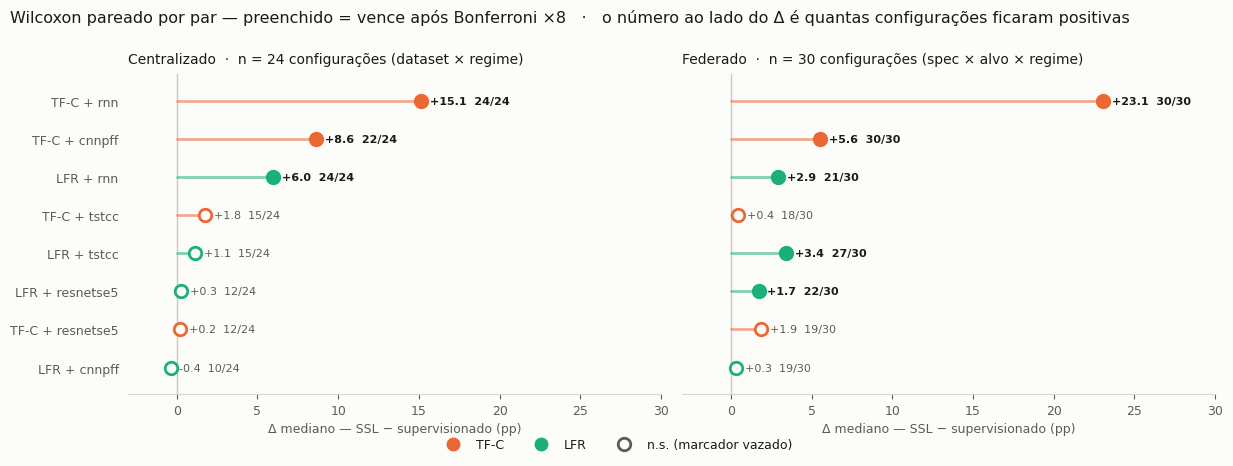

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.4), sharex=True, sharey=True)
lollipop(axes[0], dc, 'Centralizado  ·  n = 24 configurações (dataset × regime)')
lollipop(axes[1], df, 'Federado  ·  n = 30 configurações (spec × alvo × regime)')
axes[0].set_yticks(range(len(ORDEM)))
axes[0].set_yticklabels(ORDEM)
axes[0].set_xlim(-3, 30)
fig.legend(handles=LEGENDA, loc='lower center', ncol=3, frameon=False, fontsize=9,
           bbox_to_anchor=(.5, -.03))
fig.suptitle('Wilcoxon pareado por par — preenchido = vence após Bonferroni ×8'
             '   ·   o número ao lado do Δ é quantas configurações ficaram positivas',
             x=.011, ha='left', fontsize=11.5, y=1.0)
fig.tight_layout()
plt.show()

**A tabela** — obrigatória, não opcional: o verde do LFR não alcança 3:1 contra o
fundo, então a figura sozinha não pode ser o único caminho para o número.

`rbc` é a correlação bisserial de postos, `(W⁺ − W⁻)/(W⁺ + W⁻) ∈ [−1, 1]` — o
tamanho de efeito próprio do teste. O `p` sozinho só diz *"não é zero"*.

In [4]:
def tabela(d, titulo):
    v = d[['par', 'n', 'mediana', 'pos', 'rbc', 'p_bonf', 'sig']].copy()
    v = v.sort_values('mediana', ascending=False)
    v['mediana'] = v.mediana.map('{:+.2f}'.format)
    v['rbc'] = v.rbc.map(lambda x: '—' if pd.isna(x) else f'{x:+.2f}')
    v['p_bonf'] = v.p_bonf.map(lambda x: '—' if pd.isna(x)
                               else (f'{x:.1e}' if x < 1e-3 else f'{x:.4f}'))
    v.columns = ['par', 'pares', 'Δ mediano (pp)', 'Δ>0', 'rbc', 'p (Bonf.)', '']
    print(f'\n{titulo}\n' + '=' * 78)
    print(v.to_string(index=False))


tabela(dc, 'CENTRALIZADO — SSL vs supervisionado')
tabela(df, 'FEDERADO — SSL vs FedAvg supervisionado')


CENTRALIZADO — SSL vs supervisionado
             par  pares Δ mediano (pp)  Δ>0   rbc p (Bonf.)          
      TF-C + rnn     24         +15.14   24 +1.00   1.5e-04 SSL vence
   TF-C + cnnpff     24          +8.63   22 +0.97   2.4e-04 SSL vence
       LFR + rnn     24          +5.95   24 +1.00   9.5e-07 SSL vence
    TF-C + tstcc     24          +1.77   15 +0.31    1.0000      n.s.
     LFR + tstcc     24          +1.15   15 +0.36    1.0000      n.s.
 LFR + resnetse5     24          +0.27   12 +0.02    1.0000      n.s.
TF-C + resnetse5     24          +0.20   12 -0.11    1.0000      n.s.
    LFR + cnnpff     24          -0.39   10 -0.24    1.0000      n.s.

FEDERADO — SSL vs FedAvg supervisionado
             par  pares Δ mediano (pp)  Δ>0   rbc p (Bonf.)          
      TF-C + rnn     30         +23.07   30 +1.00   1.5e-08 SSL vence
   TF-C + cnnpff     30          +5.55   30 +1.00   1.5e-08 SSL vence
     LFR + tstcc     30          +3.43   27 +0.91   1.2e-04 SSL vence
       LFR 

**Concordância centralizado ↔ federado: 7/8 de sinal.** O único desalinhamento é
`LFR + cnnpff` (−0,4 centralizado, +0,3 federado) — e os dois são n.s., então não
é contradição, é ruído em torno de zero. **A conclusão sobrevive à federação.**

No federado *mais* pares passam, e isso não é um efeito da federação: a grade
federada tem 30 configurações contra 24, e mais `n` é mais poder.

## 3. O agregado por método — o teste que o benchmark de fato faz

Empilha os 4 encoders num teste só por método. É a rota do da Luz, e é o que
sustenta a afirmação agregada. Recalculado aqui pelas funções do próprio script
de análise (o agregado não está nos `.csv` de cache).

In [5]:
from analysis.wilcoxon_pares import (BENCH_T10, LAB, carrega_centralizado,
                                     carrega_federado, testa_agregado)

ag = pd.concat([testa_agregado(carrega_centralizado()).assign(setup='centralizado'),
                testa_agregado(carrega_federado()).assign(setup='federado')])
v = ag[['setup', 'metodo', 'n', 'mediana', 'p_bonf', 'sig']].copy()
v['mediana'] = v.mediana.map('{:+.2f}'.format)
v['p_bonf'] = v.p_bonf.map('{:.1e}'.format)
v.columns = ['setup', 'método', 'pares', 'Δ mediano (pp)', 'p (Bonf.)', '']
print(v.to_string(index=False))

       setup método  pares Δ mediano (pp) p (Bonf.)          
centralizado    LFR     96          +1.27   4.1e-03 SSL vence
centralizado   TF-C     96          +6.88   1.3e-07 SSL vence
    federado    LFR    120          +1.66   9.5e-11 SSL vence
    federado   TF-C    120          +4.46   7.5e-14 SSL vence


Os quatro agregados vencem com folga. **Mas é o agregado que vence** — e ele
esconde que metade dos pares individuais é indistinguível do baseline. Usar o
agregado para afirmar *"SSL melhora"* e a figura da §2 para escolher um par são
duas coisas diferentes; a §2 é a que responde "qual par".

## 4. A réplica bate na *estrutura* do efeito, não só no nível

Bater em nível contra a Tabela 10 do benchmark (MAE 1,56 pp) não autoriza o claim
— o claim usa o **Δ**. Esta figura compara o Δ deles com o nosso, par a par.

O Δ do benchmark não é digitado à mão: sai da `BENCH_T10` do script de análise,
pela mesma regra do `bloco_a2` (mediana sobre os 4 regimes da Tab. 10).

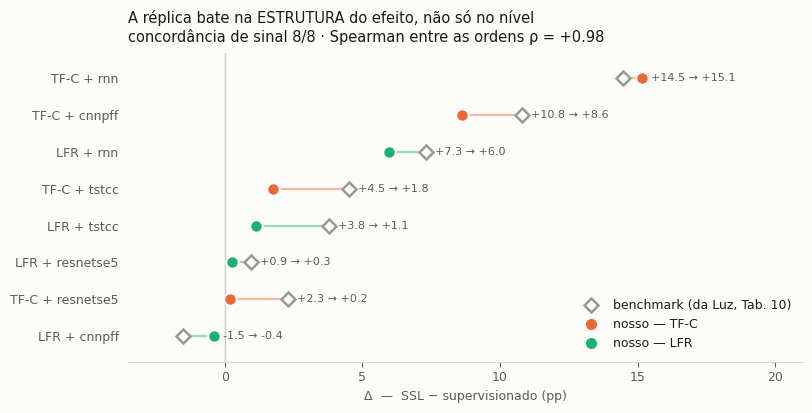

In [6]:
REGIMES = ['1', '10', '100', 'full']
BENCH = {(LAB[m], e): float(np.median([BENCH_T10[(m, e)][k] - BENCH_T10[('sup', e)][k]
                                       for k in REGIMES]))
         for m in ['lfr', 'tfc'] for e in ['resnetse5', 'cnnpff', 'rnn', 'tstcc']}
GRAY = '#9a9992'

fig, ax = plt.subplots(figsize=(8.2, 4.2))
ax.axvline(0, color=GRID, lw=1, zorder=1)
for _, r in dc.iterrows():
    y = ORDEM.index(r.par)
    b, c = BENCH[(r.metodo, r.encoder)], CM[r.metodo]
    ax.plot([b, r.mediana], [y, y], color=c, lw=1.6, alpha=.45, zorder=2,
            solid_capstyle='round')
    ax.plot(b, y, 'D', ms=7, color=SURF, mec=GRAY, mew=1.8, zorder=3)
    ax.plot(r.mediana, y, 'o', ms=9, color=c, mec=SURF, mew=1.5, zorder=4)
    ax.annotate(f'{b:+.1f} → {r.mediana:+.1f}', (max(b, r.mediana), y),
                xytext=(0.8, 0), textcoords='offset fontsize', va='center',
                ha='left', fontsize=8, color=INK2)
ax.set_yticks(range(len(ORDEM)))
ax.set_yticklabels(ORDEM)
ax.set_xlim(-3.5, 21)
ax.set_ylim(-.7, len(ORDEM) - .3)
ax.set_xlabel('Δ  —  SSL − supervisionado (pp)')
rho = pd.Series([BENCH[(r.metodo, r.encoder)] for _, r in dc.iterrows()]).corr(
    dc.mediana.reset_index(drop=True), method='spearman')
concorda = int((np.sign([BENCH[(r.metodo, r.encoder)] for _, r in dc.iterrows()])
                == np.sign(dc.mediana)).sum())
ax.set_title('A réplica bate na ESTRUTURA do efeito, não só no nível\n'
             f'concordância de sinal {concorda}/8 · Spearman entre as ordens ρ = {rho:+.2f}',
             loc='left', fontsize=10.5, color=INK, pad=8)
for s in ('top', 'right', 'left'):
    ax.spines[s].set_visible(False)
ax.tick_params(left=False)
ax.legend(handles=[
    Line2D([], [], marker='D', ls='', ms=7, color=SURF, mec=GRAY, mew=1.8,
           label='benchmark (da Luz, Tab. 10)'),
    Line2D([], [], marker='o', ls='', ms=9, color=CM['TF-C'], mec=SURF, label='nosso — TF-C'),
    Line2D([], [], marker='o', ls='', ms=9, color=CM['LFR'], mec=SURF, label='nosso — LFR')],
    frameon=False, fontsize=9, loc='lower right')
fig.tight_layout()
plt.show()

**Concordância de sinal 8/8, ρ = +0,98** — a ordem dos pares é praticamente
idêntica, inclusive o único par negativo (`LFR + cnnpff`, que no paper deles rende
62,2% contra 63,4% do supervisionado, Tab. 7).

É isso que dá o direito de invocar o benchmark: não replicamos só o número,
replicamos a *estrutura* do efeito. Note que somos **sistematicamente mais
conservadores** — quase todo Δ nosso é menor que o deles.

## 5. O piso de poder — por que `n` pequeno não tem conserto

O Wilcoxon é de postos, então com `n` pares o melhor caso possível é *todas* as
diferenças com o mesmo sinal — e aí `p = 2/2ⁿ`. Isso é um **piso**: nenhum
resultado, por mais limpo, desce abaixo dele.

Esta figura é a que explica a §6, e vale para a apresentação: ela mostra que
*"não deu significante"* às vezes é uma afirmação sobre o desenho, não sobre o efeito.

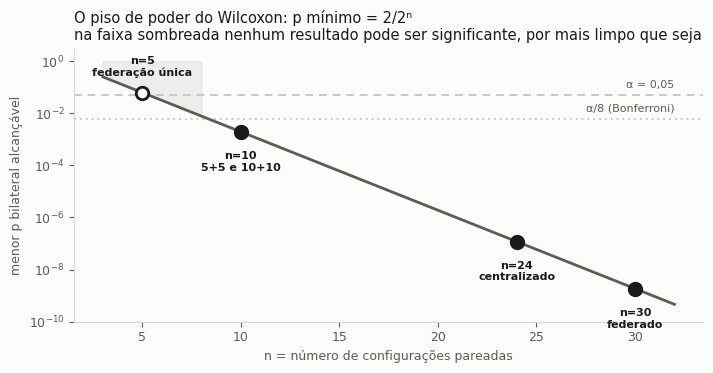

In [7]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
n = np.arange(3, 33)
piso = 2.0 / 2 ** n
ax.semilogy(n, piso, color=INK2, lw=2, zorder=3)
ax.axhline(ALFA, color=GRID, lw=1.4, ls=(0, (4, 3)), zorder=2)
ax.axhline(ALFA / FAMILIA, color=GRID, lw=1.4, ls=(0, (1, 2)), zorder=2)
ax.annotate('α = 0,05', (32, ALFA), xytext=(0, 4), textcoords='offset points',
            fontsize=8, color=INK2, va='bottom', ha='right')
ax.annotate('α/8 (Bonferroni)', (32, ALFA / FAMILIA), xytext=(0, 4),
            textcoords='offset points', fontsize=8, color=INK2, va='bottom', ha='right')
# NAO usar o laranja/verde aqui: nesta figura a distincao e de STATUS (testavel ou
# nao), e reusar as cores categoricas do TF-C/LFR faria o leitor ler "metodo" onde
# esta escrito "poder". Tudo em tinta neutra; o vazado + a faixa carregam o estado.
ax.fill_between(n, piso, 1, where=(piso > ALFA / FAMILIA), color=GRID, alpha=.28,
                zorder=1)
for nn, rot in [(5, 'federação única'), (10, '5+5 e 10+10'),
                (24, 'centralizado'), (30, 'federado')]:
    p = p_minimo(nn)
    ok = p < ALFA / FAMILIA
    ax.plot(nn, p, 'o', ms=9, color=INK if ok else SURF, mec=INK, mew=2, zorder=4)
    ax.annotate(f'n={nn}\n{rot}', (nn, p), xytext=(0, 12 if not ok else -28),
                textcoords='offset points', ha='center', fontsize=8,
                color=INK, fontweight='bold')
ax.set_xlabel('n = número de configurações pareadas')
ax.set_ylabel('menor p bilateral alcançável')
ax.set_title('O piso de poder do Wilcoxon: p mínimo = 2/2ⁿ\n'
             'na faixa sombreada nenhum resultado pode ser significante, por mais limpo que seja',
             loc='left', fontsize=10.5, color=INK)
ax.set_ylim(1e-10, 3)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)
fig.tight_layout()
plt.show()

## 6. Por federação — o Δ sobrevive, o teste não

Bonferroni recalculado **dentro** de cada federação (8 pares por spec).

As duas federações únicas (`in10-RW`, `in10-MS`) têm só 5 configurações — piso de
`p` = 0,0625, já acima de α antes de qualquer correção. **Nada ali pode ser
declarado significante, nem em princípio.** Isso não é ausência de efeito; é
ausência de teste — e o `TF-C + rnn` do `in10-MS`, com +26,2 pp e 5/5, é o caso
que deixa isso óbvio.

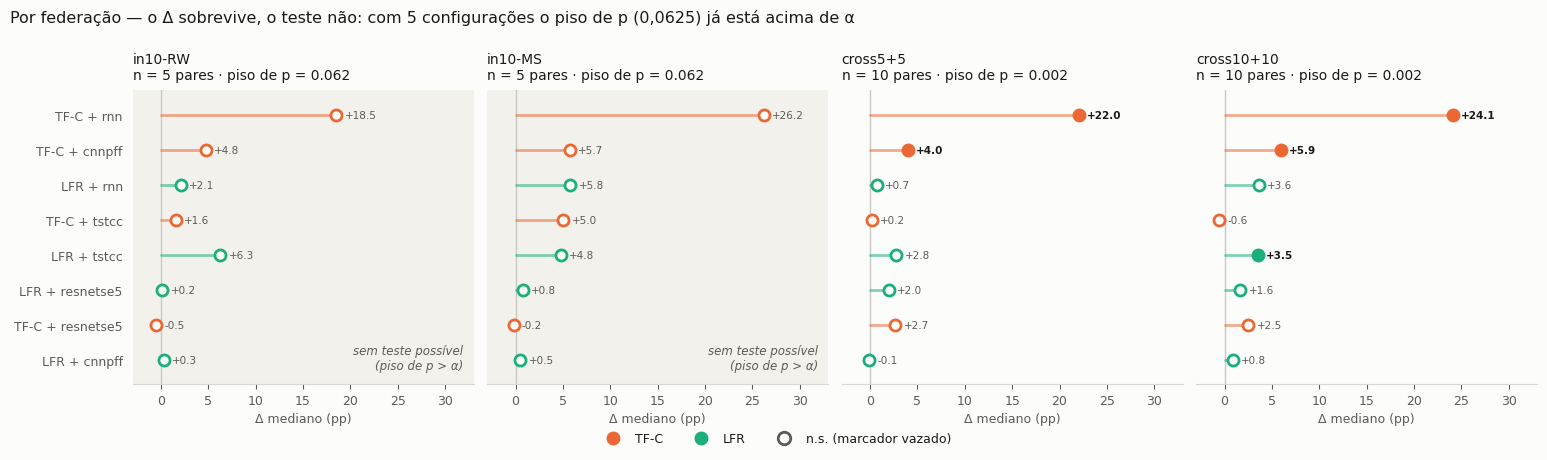

In [8]:
SPECS = [('device:RealWorld_thigh:10', 'in10-RW'),
         ('device:MotionSense:10', 'in10-MS'),
         ('device:RealWorld_thigh+MotionSense:5+5', 'cross5+5'),
         ('device:RealWorld_thigh+MotionSense:10+10', 'cross10+10')]

fig, axes = plt.subplots(1, 4, figsize=(15.5, 4.3), sharex=True, sharey=True)
for ax, (spec, rot) in zip(axes, SPECS):
    d = ds[ds.spec == spec]
    nn = int(d.n.max())
    testavel = p_minimo(nn) < ALFA / FAMILIA
    if not testavel:                     # painel sem poder: fundo levemente marcado
        ax.set_facecolor('#f2f1ec')
    lollipop(ax, d, f'{rot}\nn = {nn} pares · piso de p = {p_minimo(nn):.3f}',
             sig_label=False, ms=8, fs=7.5)
    ax.set_xlabel('Δ mediano (pp)')
    if not testavel:
        # O aviso vai DENTRO do painel: no titulo ele transborda para o vizinho.
        ax.annotate('sem teste possível\n(piso de p > α)', (.97, .04),
                    xycoords='axes fraction', ha='right', va='bottom',
                    fontsize=8.5, color=INK2, style='italic')
axes[0].set_yticks(range(len(ORDEM)))
axes[0].set_yticklabels(ORDEM)
axes[0].set_xlim(-3, 33)
fig.legend(handles=LEGENDA, loc='lower center', ncol=3, frameon=False, fontsize=9,
           bbox_to_anchor=(.5, -.04))
fig.suptitle('Por federação — o Δ sobrevive, o teste não: com 5 configurações o piso '
             'de p (0,0625) já está acima de α',
             x=.006, ha='left', fontsize=11.5, y=1.0)
fig.tight_layout()
plt.show()

In [9]:
for spec, rot in SPECS:
    tabela(ds[ds.spec == spec], f'{rot}   ({spec})')


in10-RW   (device:RealWorld_thigh:10)
             par  pares Δ mediano (pp)  Δ>0 rbc p (Bonf.)  
      TF-C + rnn      5         +18.49    5   —         — —
     LFR + tstcc      5          +6.27    4   —         — —
   TF-C + cnnpff      5          +4.76    5   —         — —
       LFR + rnn      5          +2.10    3   —         — —
    TF-C + tstcc      5          +1.58    3   —         — —
    LFR + cnnpff      5          +0.31    3   —         — —
 LFR + resnetse5      5          +0.16    4   —         — —
TF-C + resnetse5      5          -0.54    2   —         — —

in10-MS   (device:MotionSense:10)
             par  pares Δ mediano (pp)  Δ>0 rbc p (Bonf.)  
      TF-C + rnn      5         +26.20    5   —         — —
       LFR + rnn      5          +5.79    4   —         — —
   TF-C + cnnpff      5          +5.71    5   —         — —
    TF-C + tstcc      5          +5.03    5   —         — —
     LFR + tstcc      5          +4.81    5   —         — —
 LFR + resnetse5      5   

Nas duas federações mistas (`n = 10`) o piso depois do Bonferroni é 0,0156 — ou
seja, **só um placar perfeito de 10/10 sobrevive**. Não há meio-termo nessa escala,
e é exatamente o que os três vencedores fizeram.

Para as duas federações únicas a única rota é o agregado por método (`n = 20`),
que passa — está na §3 do `docs/wilcoxon_pares.md`.

## 7. Ressalvas — o que não dizer com estas figuras

**1. As configurações pareadas não são independentes.** O mesmo dataset aparece em
4 regimes, o mesmo encoder em 6 datasets. O Wilcoxon assume independência e o
Bonferroni não conserta dependência. Os `p` **ordenam evidência** com segurança;
tratá-los como probabilidades exatas seria exagero. O benchmark tem o mesmo
problema — não estamos abaixo do padrão da área —, mas convém dizer na seção de
método em vez de deixar o revisor achar.

**2. `n.s.` significa não distinguível, nunca "não ajuda".** `LFR + resnetse5` com
+0,27 pp no centralizado é honestamente um empate; `TF-C + tstcc` com +1,77 pp e
15/24 é um efeito plausível que o nosso `n` não resolve. São situações diferentes
com o mesmo rótulo.

**3. As 4 seeds bastam para claim agregado — e as 3 do benchmark também bastavam,
pelo mesmo motivo.** O `n` do teste nunca foi o número de seeds; elas servem para
*estabilizar cada célula* antes de parear. Para claim célula-a-célula não bastam,
e nem 8 seeds resolveriam a um custo razoável: `dp(Δ) ≈ 2,5 pp` com `n=4` dá IC95
de ±4 pp contra um efeito mediano de 3 pp.

**4. F7 continua em aberto** e afeta os degraus baixos de todas estas células: a
seleção few-shot usa o split de validação **cheio**, o que infla os regimes
pobres. Ver `docs/metodo_e_auditoria.md` §F7. Como o viés atinge os dois braços da
diferença, o Δ é menos afetado que o nível — mas "menos" não é "nada".